# 05 — Qubit Spectroscopy & Pulse Calibration

## Purpose

Locate the qubit transition frequency (g→e) via spectroscopy and calibrate the fundamental π-pulse amplitude and duration through Rabi oscillation measurements. These calibrations are prerequisites for all subsequent qubit-manipulation experiments.

## Methodology

1. **Qubit spectroscopy** — sweep the qubit drive frequency while monitoring the readout response. A Lorentzian dip (or peak) identifies the g→e transition frequency. Multiple trial pulse configurations are tested in priority order to find a reliable spectroscopy signal.
2. **Primitive pulse seeding** — register a reference π-pulse (`ref_r180`) and derive the standard rotation set (x180, x90, y180, y90, etc.) via DRAG-Gaussian waveforms.
3. **Power Rabi** — sweep the drive amplitude at the calibrated qubit frequency. The first oscillation minimum determines the π-pulse gain ($g_\pi$), which refines the `ref_r180` amplitude.
4. **Temporal Rabi** — sweep the pulse duration at fixed amplitude to confirm the π-pulse length. This provides a cross-check of the power Rabi result.

Each calibration step can be independently enabled/disabled via `APPLY_*_CALIBRATION` flags.

## Expected Outcomes

- Qubit frequency fitted within the spectroscopy window with r² > 0.5
- Power Rabi oscillations visible with a clear first minimum (π-pulse gain)
- Temporal Rabi oscillations with a well-defined π-length
- Calibration patches committed to the session for use in coherence experiments

## Prerequisites

- **Notebook 00** — hardware session established
- **Notebook 03** — resonator frequency identified (for correct readout placement)
- **Notebook 04** — readout operating point characterized (advisory)

## 1. Setup — Session Bootstrap

Open the notebook stage, load the prior resonator power chevron checkpoint, and initialize session attributes.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from qualang_tools.units import unit

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "qubox").exists():
    REPO_ROOT = Path(r"E:\qubox")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from qubox.notebook import (
    PowerRabi,
    QubitSpectroscopy,
    TemporalRabi,
    ensure_primitive_rotations,
    fit_center_inside_window,
    load_stage_checkpoint,
    open_notebook_stage,
    preview_or_apply_patch_ops,
    save_stage_checkpoint,
)

REGISTRY_BASE = Path(r"E:\qubox")
SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2026_03_24"
QOP_IP = "10.157.36.68"
CLUSTER_NAME = "Cluster_2"

stage = open_notebook_stage(
    stage_name="05_qubit_spectroscopy_pulse_calibration",
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    qop_ip=QOP_IP,
    cluster_name=CLUSTER_NAME,
    force_reopen=True,
    close_existing=True,
)
session = stage.session
attr = stage.attr
SESSION_BOOTSTRAP_PATH = stage.bootstrap_path
u = unit(coerce_to_integer=True)
INITIAL_QB_FQ_HZ = float(attr.qb_fq)
primitive_seed_result = None

resonator_power_checkpoint = load_stage_checkpoint(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    stage_name="04_resonator_power_chevron",
)

print(f"Repo root on sys.path: {REPO_ROOT}")
print(f"Shared session bootstrap: {SESSION_BOOTSTRAP_PATH}")
print(f"Stage checkpoint path: {stage.checkpoint_path}")
print(f"Closed a live in-memory session before reopen: {stage.had_live_session}")
print(f"QM endpoint: {QOP_IP} ({CLUSTER_NAME})")
print(f"Current qubit frequency: {float(attr.qb_fq) / 1e9:.6f} GHz")
if resonator_power_checkpoint is not None:
    print(
        "Prior stage 04 status: "
        f"{resonator_power_checkpoint['status']}"
        f" ({resonator_power_checkpoint['summary']})"
    )
    optimal_freq_hz = resonator_power_checkpoint.get("advisory_outputs", {}).get("optimal_freq_hz")
    optimal_gain = resonator_power_checkpoint.get("advisory_outputs", {}).get("optimal_gain")
    if optimal_freq_hz is not None and optimal_gain is not None:
        print(
            "Stage 04 advisory operating point: "
            f"{float(optimal_freq_hz) / 1e9:.6f} GHz at gain {float(optimal_gain):.6f}"
        )

2026-03-24 01:54:41,460 - qm - INFO     - Starting session: 40d2b3f3-6156-4f01-ab7c-1f9c8e58cf51
2026-03-24 01:54:46,451 - qm - INFO     - Performing health check
2026-03-24 01:54:46,456 - qm - INFO     - Health check passed


e:\qubox\.venv\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


Repo root on sys.path: E:\qubox
Shared session bootstrap: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\runtime\notebook_session.json
Stage checkpoint path: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\runtime\notebook_stage_05_qubit_spectroscopy_pulse_calibration.json
Closed a live in-memory session before reopen: False
QM endpoint: 10.157.36.68 (Cluster_2)
Current qubit frequency: 6.150359 GHz
Prior stage 04 status: characterized (Characterized the resonator operating point without applying calibration changes.)
Stage 04 advisory operating point: 8.593023 GHz at gain 0.817765


## 2. Configuration — Experiment and Pulse Defaults

Define the spectroscopy sweep window, pulse seed parameters, and Rabi measurement settings. The trial settings list controls the priority order for spectroscopy — each trial uses a different pulse configuration until a trustworthy fit is obtained.

In [4]:
APPLY_QUBIT_SPECTROSCOPY_CALIBRATION = True
APPLY_POWER_RABI_CALIBRATION = True
APPLY_TEMPORAL_RABI_CALIBRATION = False

QUBIT_SPEC_N_AVG = 5000
QUBIT_SPEC_RF_BEGIN = 6135 * u.MHz
QUBIT_SPEC_RF_END = 6155 * u.MHz
QUBIT_SPEC_DF = 250 * u.kHz
QUBIT_SPEC_EDGE_MARGIN_POINTS = 2
QUBIT_SPEC_MAX_GAMMA_FRACTION_OF_SPAN = 0.5
QUBIT_SPEC_MIN_R_SQUARED = 0.5
QUBIT_SPEC_TRIAL_SETTINGS = [
    {"pulse": "x180", "qb_gain": 1.0, "qb_len": None, "label": "x180 default"},
    {"pulse": "ref_r180", "qb_gain": 1.0, "qb_len": None, "label": "seeded ref_r180"},
]

REF_R180_LEN_NS = 16
REF_R180_AMPLITUDE = 0.08565235748770193
REF_R180_SIGMA_NS = REF_R180_LEN_NS / 6
REF_R180_ALPHA = 0.0
REF_R180_ANHARMONICITY_HZ = float(getattr(attr, "anharmonicity", -255e6) or -255e6)
REF_R180_DETUNING_HZ = 0.0
REF_R180_SAMPLING_RATE = 1e9
CONST_R180_AMPLITUDE = 0.02488 / 2 * 0.8129
CONST_R180_LEN = 200

POWER_RABI_MAX_GAIN = 1.2
POWER_RABI_DG = 0.04
POWER_RABI_N_AVG = 2000
POWER_RABI_QB_THERM_CLKS = int(getattr(attr, "qb_therm_clks", 10000) or 10000)
POWER_RABI_OP_CANDIDATES = ("ref_r180", "ge_ref_r180", "x180")

TEMPORAL_RABI_PULSE = "const"
TEMPORAL_RABI_LEN_BEGIN = 16
TEMPORAL_RABI_LEN_END = 500
TEMPORAL_RABI_DT = 4
TEMPORAL_RABI_N_AVG = 2000
TEMPORAL_RABI_QB_THERM_CLKS = int(getattr(attr, "qb_therm_clks", 10000) or 10000)

print("Notebook 05 verification settings (REFINED):")
print(f"  apply qubit-frequency calibration: {APPLY_QUBIT_SPECTROSCOPY_CALIBRATION}")
print(f"  apply power-Rabi amplitude calibration: {APPLY_POWER_RABI_CALIBRATION}")
print(f"  apply temporal-Rabi pi-length calibration: {APPLY_TEMPORAL_RABI_CALIBRATION}")
print(f"  qubit spec window: {QUBIT_SPEC_RF_BEGIN / 1e9:.6f} -> {QUBIT_SPEC_RF_END / 1e9:.6f} GHz")
print(f"  qubit spec df: {QUBIT_SPEC_DF / 1e3:.0f} kHz")
print(f"  qubit spec n_avg: {QUBIT_SPEC_N_AVG}")
print("  qubit spectroscopy trial settings:")
for trial in QUBIT_SPEC_TRIAL_SETTINGS:
    print(f"    - {trial['label']}: pulse={trial['pulse']}, gain={trial['qb_gain']}, qb_len={trial['qb_len']}")
print(f"  qb_therm_clks (power Rabi): {POWER_RABI_QB_THERM_CLKS}")
print(f"  qb_therm_clks (temporal Rabi): {TEMPORAL_RABI_QB_THERM_CLKS}")

Notebook 05 verification settings (REFINED):
  apply qubit-frequency calibration: True
  apply power-Rabi amplitude calibration: True
  apply temporal-Rabi pi-length calibration: False
  qubit spec window: 6.135000 -> 6.155000 GHz
  qubit spec df: 250 kHz
  qubit spec n_avg: 5000
  qubit spectroscopy trial settings:
    - x180 default: pulse=x180, gain=1.0, qb_len=None
    - seeded ref_r180: pulse=ref_r180, gain=1.0, qb_len=None
  qb_therm_clks (power Rabi): 20000
  qb_therm_clks (temporal Rabi): 20000


Primitive seed pulse already existed; using the generated reference waveform only for diagnostics.

Trial 1: x180 default
  pulse=x180, qb_gain=1.0, qb_len=16, n_avg=5000
2026-03-24 01:57:07,285 - qm - INFO     - Sending program to QOP for compilation
2026-03-24 01:57:07,372 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:32<00:00, 152.96it/s]


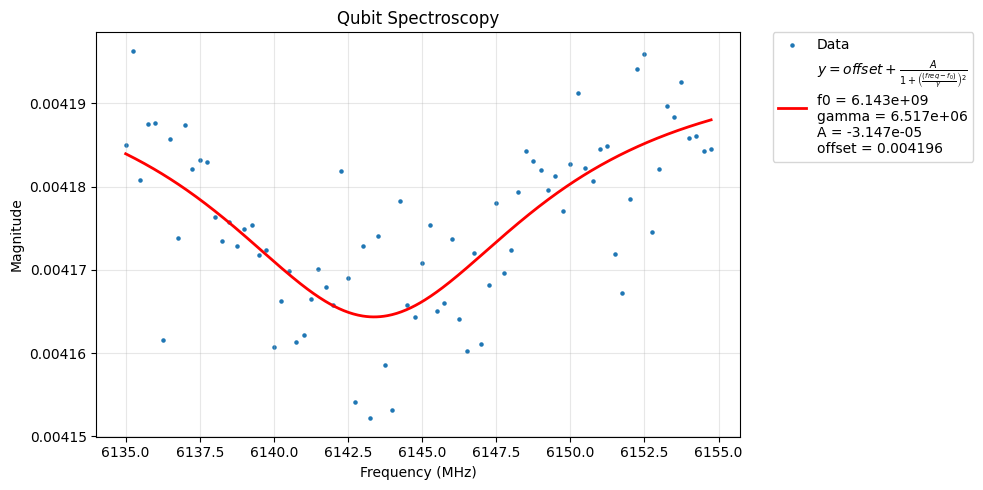

  fitted qb_f0: 6.143379 GHz
  fitted gamma: 6.517 MHz
  fitted r_squared: 0.549834
  trust gate: fit center lies safely inside the scan window
Qubit spectroscopy frequency calibration via x180 patch preview (1 updates):
  1. SetCalibration: {'path': 'cqed_params.transmon.qubit_freq', 'value': 6143379092.650647}
Applied patch with 1 updates; sync_ok=True
Updated runtime qubit frequency: 6.143379 GHz
Selected spectroscopy trial: {'pulse': 'x180', 'qb_gain': 1.0, 'qb_len': None, 'label': 'x180 default', 'resolved_qb_len': 16}
Final fitted qubit frequency: 6.143379 GHz
Runtime attr.qb_fq delta: +0.000 MHz


In [5]:
primitive_seed_result = ensure_primitive_rotations(
    session,
    qb_element=attr.qb_el,
    amplitude=float(REF_R180_AMPLITUDE),
    length=int(REF_R180_LEN_NS),
    sigma=float(REF_R180_SIGMA_NS),
    alpha=float(REF_R180_ALPHA),
    anharmonicity_hz=float(REF_R180_ANHARMONICITY_HZ),
    detuning_hz=float(REF_R180_DETUNING_HZ),
    sampling_rate=float(REF_R180_SAMPLING_RATE),
    required_ops=("ref_r180",),
    rotations=("ref_r180", "x180", "x90", "xn90", "y180", "y90", "yn90"),
    ref_op="ref_r180",
)
if primitive_seed_result["created"]:
    print(f"Seeded primitive operations before qubit spectroscopy: {primitive_seed_result['created_ops']}")
else:
    print("Primitive seed pulse already existed; using the generated reference waveform only for diagnostics.")

pulse_mgr = session.pulse_mgr
available_qubit_spec_ops = {}
for trial in QUBIT_SPEC_TRIAL_SETTINGS:
    pulse_name = trial["pulse"]
    if pulse_name in available_qubit_spec_ops:
        continue
    try:
        pulse_info = pulse_mgr.get_pulseOp_by_element_op(attr.qb_el, pulse_name, strict=True)
        available_qubit_spec_ops[pulse_name] = pulse_info
    except Exception:
        continue

qubit_spec = QubitSpectroscopy(session)
qubit_analysis = None
qubit_result = None
qubit_patch = None
qubit_patch_preview = None
qubit_apply_result = None
chosen_qubit_spec_trial = None

for trial_index, trial in enumerate(QUBIT_SPEC_TRIAL_SETTINGS, start=1):
    pulse_name = trial["pulse"]
    pulse_info = available_qubit_spec_ops.get(pulse_name)
    if pulse_info is None:
        print(f"Skipping trial {trial_index}: pulse {pulse_name!r} is not registered on {attr.qb_el}.")
        continue

    if trial["qb_len"] is None:
        resolved_qb_len = getattr(pulse_info, "length", None)
    else:
        resolved_qb_len = int(trial["qb_len"])
    if resolved_qb_len is None:
        print(f"Skipping trial {trial_index}: pulse {pulse_name!r} has no resolvable duration.")
        continue

    print(f"\nTrial {trial_index}: {trial['label']}")
    print(f"  pulse={pulse_name}, qb_gain={trial['qb_gain']}, qb_len={resolved_qb_len}, n_avg={QUBIT_SPEC_N_AVG}")

    trial_result = qubit_spec.run(
        pulse=pulse_name,
        rf_begin=QUBIT_SPEC_RF_BEGIN,
        rf_end=QUBIT_SPEC_RF_END,
        df=QUBIT_SPEC_DF,
        qb_gain=float(trial["qb_gain"]),
        qb_len=int(resolved_qb_len),
        n_avg=QUBIT_SPEC_N_AVG,
        qb_therm_clks=POWER_RABI_QB_THERM_CLKS,
    )
    trial_analysis = qubit_spec.analyze(trial_result, update_calibration=True)
    qubit_spec.plot(trial_analysis)

    fitted_qb_f0_hz = float(trial_analysis.metrics.get("f0", np.nan))
    fitted_gamma_hz = float(trial_analysis.metrics.get("gamma", np.nan))
    qubit_freqs_hz = np.asarray(trial_analysis.data.get("frequencies", []), dtype=float)
    fit_ok, fit_reason = fit_center_inside_window(
        fitted_qb_f0_hz,
        qubit_freqs_hz,
        margin_points=QUBIT_SPEC_EDGE_MARGIN_POINTS,
    )
    if fit_ok and qubit_freqs_hz.size:
        sweep_span_hz = float(qubit_freqs_hz.max() - qubit_freqs_hz.min())
        if np.isfinite(fitted_gamma_hz) and fitted_gamma_hz > QUBIT_SPEC_MAX_GAMMA_FRACTION_OF_SPAN * sweep_span_hz:
            fit_ok = False
            fit_reason = (
                f"fit linewidth is too broad for the scan window: gamma={fitted_gamma_hz / 1e6:.3f} MHz, "
                f"span={sweep_span_hz / 1e6:.3f} MHz"
            )
    trial_fit = getattr(trial_analysis, "fit", None)
    trial_r_squared = getattr(trial_fit, "r_squared", np.nan) if trial_fit is not None else np.nan
    if fit_ok and np.isfinite(trial_r_squared) and trial_r_squared < QUBIT_SPEC_MIN_R_SQUARED:
        fit_ok = False
        fit_reason = f"fit r_squared below threshold: {trial_r_squared:.3f} < {QUBIT_SPEC_MIN_R_SQUARED:.3f}"

    print(f"  fitted qb_f0: {fitted_qb_f0_hz / 1e9:.6f} GHz")
    print(f"  fitted gamma: {fitted_gamma_hz / 1e6:.3f} MHz")
    print(f"  fitted r_squared: {trial_r_squared:.6f}")
    print(f"  trust gate: {fit_reason}")

    qubit_result = trial_result
    qubit_analysis = trial_analysis
    chosen_qubit_spec_trial = {**trial, "resolved_qb_len": int(resolved_qb_len)}

    if fit_ok:
        qubit_patch, qubit_patch_preview, qubit_apply_result = preview_or_apply_patch_ops(
            session,
            reason=f"Qubit spectroscopy frequency calibration via {pulse_name}",
            proposed_patch_ops=trial_analysis.metadata.get("proposed_patch_ops", []),
            apply=APPLY_QUBIT_SPECTROSCOPY_CALIBRATION,
        )
        break

if qubit_analysis is None:
    raise RuntimeError("No qubit spectroscopy trial could be executed with the currently registered pulses.")

if qubit_patch is None:
    print("No trustworthy spectroscopy fit was found across the current rough-guess trials.")
    print("Suppressing calibration apply for this notebook pass.")

if qubit_apply_result is not None:
    context_snapshot = getattr(session, "context_snapshot", None)
    attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attributes", None)
    if attr is None:
        raise RuntimeError("Calibration applied, but the refreshed cQED attribute snapshot is unavailable.")
    print(f"Updated runtime qubit frequency: {float(attr.qb_fq) / 1e9:.6f} GHz")

final_fitted_qb_f0_hz = float(qubit_analysis.metrics.get("f0", np.nan))
print(f"Selected spectroscopy trial: {chosen_qubit_spec_trial}")
print(f"Final fitted qubit frequency: {final_fitted_qb_f0_hz / 1e9:.6f} GHz")
print(f"Runtime attr.qb_fq delta: {(final_fitted_qb_f0_hz - float(attr.qb_fq)) / 1e6:+.3f} MHz")

In [6]:
context_snapshot = getattr(session, "context_snapshot", None)
current_attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attributes", None)
print(f"Current runtime qb_fq: {float(current_attr.qb_fq) / 1e9:.6f} GHz")
print(f"Bootstrap snapshot qb_fq: {INITIAL_QB_FQ_HZ / 1e9:.6f} GHz")
if "chosen_qubit_spec_trial" in globals():
    print(f"Chosen spectroscopy trial: {chosen_qubit_spec_trial}")
if "qubit_analysis" in globals():
    latest_fitted_qb_f0_hz = float(qubit_analysis.metrics.get("f0", np.nan))
    latest_gamma_hz = float(qubit_analysis.metrics.get("gamma", np.nan))
    print(f"Latest fitted qb_f0: {latest_fitted_qb_f0_hz / 1e9:.6f} GHz")
    print(f"Latest fit gamma: {latest_gamma_hz / 1e6:.3f} MHz")
    print(f"Proposed patch ops: {qubit_analysis.metadata.get('proposed_patch_ops', [])}")
    latest_freqs_hz = np.asarray(qubit_analysis.data.get("frequencies", []), dtype=float)
    fit_ok, fit_reason = fit_center_inside_window(
        latest_fitted_qb_f0_hz,
        latest_freqs_hz,
        margin_points=QUBIT_SPEC_EDGE_MARGIN_POINTS,
    )
    if fit_ok and latest_freqs_hz.size:
        latest_span_hz = float(latest_freqs_hz.max() - latest_freqs_hz.min())
        if np.isfinite(latest_gamma_hz) and latest_gamma_hz > QUBIT_SPEC_MAX_GAMMA_FRACTION_OF_SPAN * latest_span_hz:
            fit_ok = False
            fit_reason = (
                f"fit linewidth is too broad for the scan window: gamma={latest_gamma_hz / 1e6:.3f} MHz, "
                f"span={latest_span_hz / 1e6:.3f} MHz"
            )
    latest_fit = getattr(qubit_analysis, "fit", None)
    latest_r_squared = getattr(latest_fit, "r_squared", np.nan) if latest_fit is not None else np.nan
    if fit_ok and np.isfinite(latest_r_squared) and latest_r_squared < QUBIT_SPEC_MIN_R_SQUARED:
        fit_ok = False
        fit_reason = f"fit r_squared below threshold: {latest_r_squared:.3f} < {QUBIT_SPEC_MIN_R_SQUARED:.3f}"
    print(f"Trust gate: {fit_reason}")
    print(f"Latest fit r_squared: {latest_r_squared:.6f}")
if "qubit_apply_result" in globals():
    print(f"qubit_apply_result: {qubit_apply_result}")

Current runtime qb_fq: 6.143379 GHz
Bootstrap snapshot qb_fq: 6.150359 GHz
Chosen spectroscopy trial: {'pulse': 'x180', 'qb_gain': 1.0, 'qb_len': None, 'label': 'x180 default', 'resolved_qb_len': 16}
Latest fitted qb_f0: 6.143379 GHz
Latest fit gamma: 6.517 MHz
Proposed patch ops: [{'op': 'SetCalibration', 'payload': {'path': 'cqed_params.transmon.qubit_freq', 'value': 6143379092.650647}}]
Trust gate: fit center lies safely inside the scan window
Latest fit r_squared: 0.549834
qubit_apply_result: {'dry_run': False, 'n_updates': 1, 'preview': [{'op': 'SetCalibration', 'payload': {'path': 'cqed_params.transmon.qubit_freq', 'value': 6143379092.650647}}], 'sync_ok': True}


## 3. Execution — Pulse Registration, Power Rabi, Temporal Rabi, and Checkpoint

Register the `ref_r180` seed pulse and primitive rotations, then run the Power Rabi and Temporal Rabi experiments to refine pulse parameters. Results are plotted inline and the stage checkpoint is saved at the end.

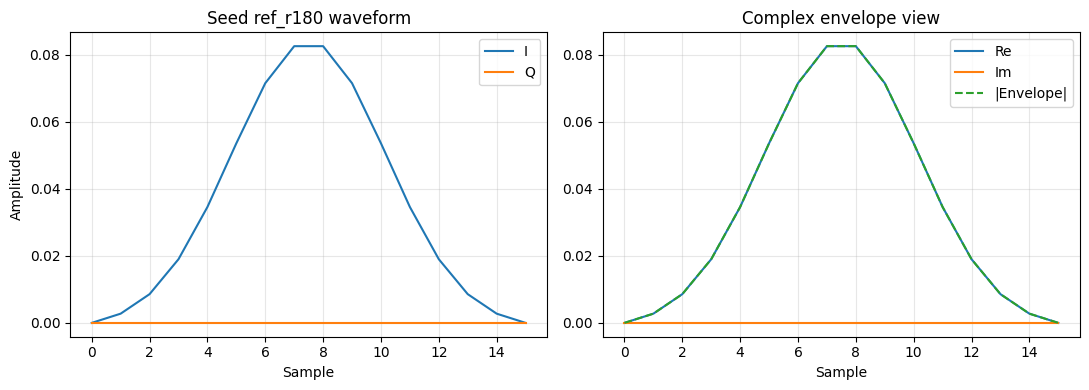

Primitive operations already existed; no additional pulse registration was required in this cell.


In [7]:
if primitive_seed_result is None:
    primitive_seed_result = ensure_primitive_rotations(
        session,
        qb_element=attr.qb_el,
        amplitude=float(REF_R180_AMPLITUDE),
        length=int(REF_R180_LEN_NS),
        sigma=float(REF_R180_SIGMA_NS),
        alpha=float(REF_R180_ALPHA),
        anharmonicity_hz=float(REF_R180_ANHARMONICITY_HZ),
        detuning_hz=float(REF_R180_DETUNING_HZ),
        sampling_rate=float(REF_R180_SAMPLING_RATE),
        required_ops=("ref_r180",),
        rotations=("ref_r180", "x180", "x90", "xn90", "y180", "y90", "yn90"),
        ref_op="ref_r180",
    )

ref_i_samples = np.asarray(primitive_seed_result["ref_i_samples"], dtype=float)
ref_q_samples = np.asarray(primitive_seed_result["ref_q_samples"], dtype=float)
complex_envelope = ref_i_samples + 1j * ref_q_samples

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ref_i_samples, label="I")
axes[0].plot(ref_q_samples, label="Q")
axes[0].set_title("Seed ref_r180 waveform")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(np.real(complex_envelope), label="Re")
axes[1].plot(np.imag(complex_envelope), label="Im")
axes[1].plot(np.abs(complex_envelope), label="|Envelope|", ls="--")
axes[1].set_title("Complex envelope view")
axes[1].set_xlabel("Sample")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

if primitive_seed_result["created"]:
    print("Registered operations:")
    for op_name in primitive_seed_result["created_ops"]:
        print(f"  {op_name}")
else:
    print("Primitive operations already existed; no additional pulse registration was required in this cell.")

2026-03-24 01:58:00,207 - qm - INFO     - Sending program to QOP for compilation
2026-03-24 01:58:00,284 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 1999/2000 [00:09<00:00, 200.38it/s]
E:\qubox\qubox_tools\fitting\routines.py:193: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


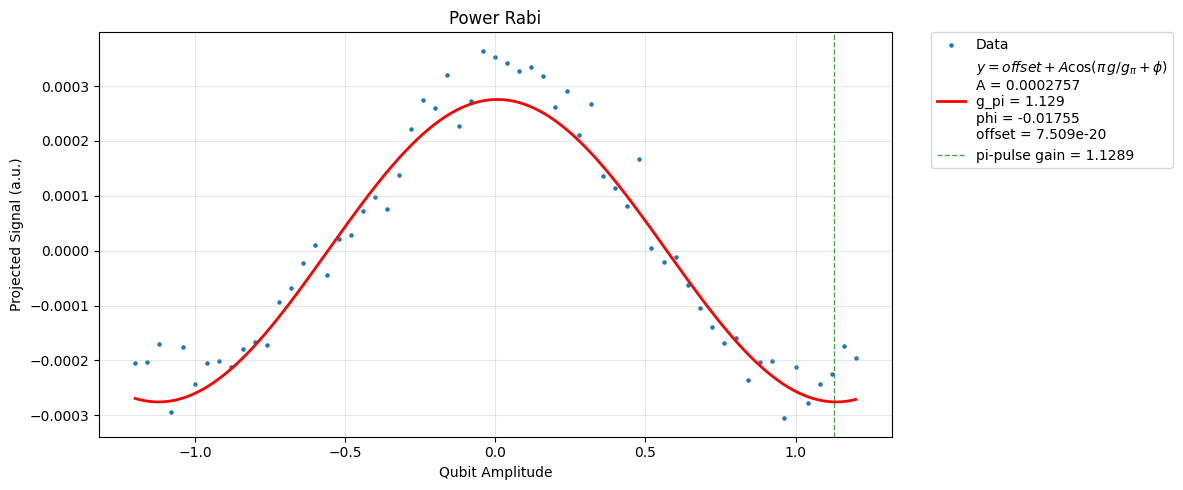

open_qm() called while QM already open; closing existing instance first.


Power Rabi amplitude calibration for ref_r180 patch preview (2 updates):
  1. SetCalibration: {'path': 'pulse_calibrations.ref_r180.amplitude', 'value': 1.1289220019456283}
  2. TriggerPulseRecompile: {'include_volatile': True}


e:\qubox\.venv\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


Applied patch with 2 updates; sync_ok=True
Power Rabi g_pi: 1.128922
Suggested ref_r180 amplitude from seed: 0.096695


In [8]:
available_power_rabi_op = None
for candidate in POWER_RABI_OP_CANDIDATES:
    try:
        session.pulse_mgr.get_pulseOp_by_element_op(attr.qb_el, candidate, strict=True)
        available_power_rabi_op = candidate
        break
    except Exception:
        continue

if available_power_rabi_op is None:
    available_power_rabi_op = POWER_RABI_OP_CANDIDATES[0]

power_rabi = PowerRabi(session)
power_rabi_result = power_rabi.run(
    max_gain=POWER_RABI_MAX_GAIN,
    dg=POWER_RABI_DG,
    op=available_power_rabi_op,
    n_avg=POWER_RABI_N_AVG,
    qb_therm_clks=POWER_RABI_QB_THERM_CLKS,
)
power_rabi_analysis = power_rabi.analyze(power_rabi_result, update_calibration=True)
power_rabi.plot(power_rabi_analysis)

power_rabi_patch, power_rabi_patch_preview, power_rabi_apply_result = preview_or_apply_patch_ops(
    session,
    reason=f"Power Rabi amplitude calibration for {available_power_rabi_op}",
    proposed_patch_ops=power_rabi_analysis.metadata.get("proposed_patch_ops", []),
    apply=APPLY_POWER_RABI_CALIBRATION,
)

g_pi = float(power_rabi_analysis.metrics.get("g_pi", np.nan))
suggested_amp = REF_R180_AMPLITUDE * g_pi if np.isfinite(g_pi) else np.nan
print(f"Power Rabi g_pi: {g_pi:.6f}")
print(f"Suggested ref_r180 amplitude from seed: {suggested_amp:.6f}")

2026-03-24 01:58:23,094 - qm - INFO     - Sending program to QOP for compilation
2026-03-24 01:58:23,163 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 1999/2000 [00:19<00:00, 100.46it/s]
E:\qubox\qubox_tools\fitting\routines.py:193: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


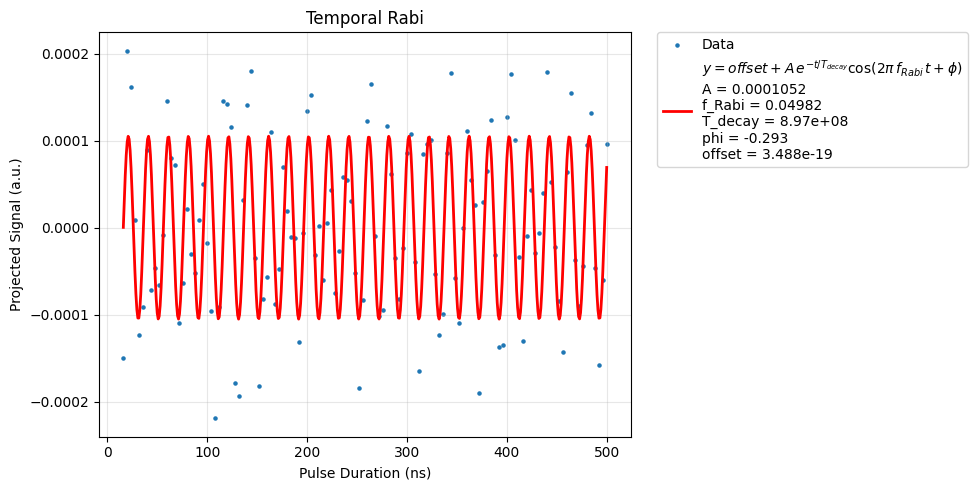

Temporal Rabi pi length estimate: 10.035736 ns
Temporal Rabi pi-length calibration for const patch preview (2 updates):
  1. SetCalibration: {'path': 'pulse_calibrations.const.pi_length', 'value': 10.035735905042612}
  2. TriggerPulseRecompile: {'include_volatile': True}
Patch not applied. Enable the stage apply flag to commit the calibration.
Stage checkpoint saved to: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\runtime\notebook_stage_05_qubit_spectroscopy_pulse_calibration.json


In [9]:
temporal_rabi = TemporalRabi(session)
temporal_rabi_result = temporal_rabi.run(
    pulse=TEMPORAL_RABI_PULSE,
    pulse_len_begin=TEMPORAL_RABI_LEN_BEGIN,
    pulse_len_end=TEMPORAL_RABI_LEN_END,
    dt=TEMPORAL_RABI_DT,
    n_avg=TEMPORAL_RABI_N_AVG,
    qb_therm_clks=TEMPORAL_RABI_QB_THERM_CLKS,
)
temporal_rabi_analysis = temporal_rabi.analyze(temporal_rabi_result, update_calibration=False)
temporal_rabi.plot(temporal_rabi_analysis)

pi_length_ns = float(temporal_rabi_analysis.metrics.get("pi_length", np.nan))
print(f"Temporal Rabi pi length estimate: {pi_length_ns:.6f} ns")

temporal_patch = None
temporal_patch_preview = None
temporal_apply_result = None
if np.isfinite(pi_length_ns):
    temporal_patch, temporal_patch_preview, temporal_apply_result = preview_or_apply_patch_ops(
        session,
        reason=f"Temporal Rabi pi-length calibration for {TEMPORAL_RABI_PULSE}",
        proposed_patch_ops=[
            {
                "op": "SetCalibration",
                "payload": {
                    "path": f"pulse_calibrations.{TEMPORAL_RABI_PULSE}.pi_length",
                    "value": pi_length_ns,
                },
            },
            {
                "op": "TriggerPulseRecompile",
                "payload": {"include_volatile": True},
            },
        ],
        apply=APPLY_TEMPORAL_RABI_CALIBRATION,
    )

context_snapshot = getattr(session, "context_snapshot", None)
attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attributes", None)
if attr is None:
    raise RuntimeError("Unable to refresh the cQED attribute snapshot at the end of notebook 05.")

stage_checkpoint_path = save_stage_checkpoint(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    stage_name="05_qubit_spectroscopy_pulse_calibration",
    status="calibrated" if any(result is not None for result in (qubit_apply_result, power_rabi_apply_result, temporal_apply_result)) else "characterized",
    summary="Ran qubit spectroscopy plus pulse calibrations and committed only the operator-approved updates.",
    consumed_inputs={
        "qubit_spec_window_hz": [QUBIT_SPEC_RF_BEGIN, QUBIT_SPEC_RF_END],
        "qubit_spec_n_avg": QUBIT_SPEC_N_AVG,
        "power_rabi_n_avg": POWER_RABI_N_AVG,
        "temporal_rabi_n_avg": TEMPORAL_RABI_N_AVG,
    },
    persisted_outputs={
        "qubit_frequency_applied": qubit_apply_result is not None,
        "power_rabi_applied": power_rabi_apply_result is not None,
        "temporal_rabi_applied": temporal_apply_result is not None,
        "runtime_qb_fq_hz": float(attr.qb_fq),
    },
    advisory_outputs={
        "selected_qubit_trial": chosen_qubit_spec_trial,
        "fitted_qb_f0_hz": float(qubit_analysis.metrics.get("f0", np.nan)) if qubit_analysis is not None else np.nan,
        "power_rabi_g_pi": float(power_rabi_analysis.metrics.get("g_pi", np.nan)) if power_rabi_analysis is not None else np.nan,
        "temporal_rabi_pi_length_ns": pi_length_ns,
    },
    next_stage="06_coherence_experiments",
    notes=[
        "Primitive pulse seeding is now handled by the shared compat workflow helper.",
        "Notebook 06 may assume the committed pulse and qubit-frequency calibrations only when the matching applied flag is true in this checkpoint.",
    ],
    metrics={
        "qubit": dict(qubit_analysis.metrics) if qubit_analysis is not None else {},
        "power_rabi": dict(power_rabi_analysis.metrics) if power_rabi_analysis is not None else {},
        "temporal_rabi": dict(temporal_rabi_analysis.metrics) if temporal_rabi_analysis is not None else {},
    },
)
print(f"Stage checkpoint saved to: {stage_checkpoint_path}")

## 4. Analysis — Sweep vs. Response Diagnostics

Comprehensive diagnostic plots showing sweep parameter vs. measured response for all three experiments:
- **Qubit spectroscopy** — frequency vs. magnitude and phase, with fitted center and runtime frequency markers
- **Power Rabi** — gain vs. projected signal, with π-gain marker
- **Temporal Rabi** — duration vs. projected signal, with π-length marker

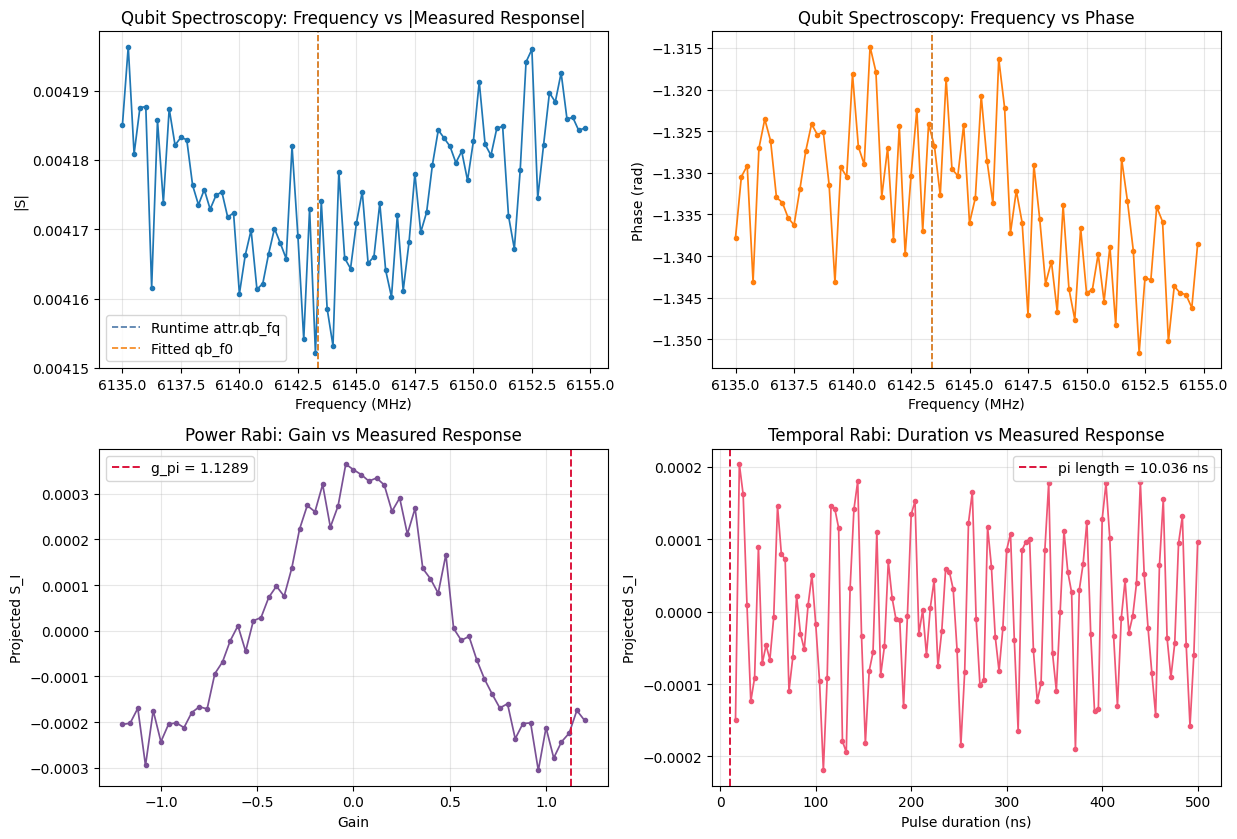

Fitted qubit frequency: 6.143379 GHz
Runtime delta: +0.000 MHz
Suggested ref_r180 amplitude: 0.096695
Temporal Rabi pi length estimate: 10.035736 ns


In [10]:
from qubox_tools.algorithms.transforms import project_complex_to_line_real


def project_signal_i(samples):
    samples = np.asarray(samples)
    if samples.size == 0:
        return np.array([])
    projected, _, _ = project_complex_to_line_real(samples)
    return np.asarray(projected, dtype=float)


has_qubit = "qubit_analysis" in globals()
has_power = "power_rabi_analysis" in globals()
has_temporal = "temporal_rabi_analysis" in globals()

if not any((has_qubit, has_power, has_temporal)):
    print("Run qubit spectroscopy, power Rabi, or temporal Rabi above to populate the sweep-versus-response diagnostics.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))
    for ax in axes.ravel():
        ax.set_visible(False)

    if has_qubit:
        qubit_S = np.asarray(qubit_analysis.data.get("S", []))
        qubit_freqs_hz = np.asarray(qubit_analysis.data.get("frequencies", []), dtype=float)
        if qubit_S.size and qubit_freqs_hz.size:
            freq_mhz = qubit_freqs_hz / 1e6
            qubit_magnitude = np.abs(qubit_S)
            qubit_phase = np.unwrap(np.angle(qubit_S))
            fitted_qb_f0_hz = float(qubit_analysis.metrics.get("f0", np.nan))

            ax_mag = axes[0, 0]
            ax_phase = axes[0, 1]
            ax_mag.set_visible(True)
            ax_phase.set_visible(True)

            ax_mag.plot(freq_mhz, qubit_magnitude, marker="o", ms=3, lw=1.25, color="#1f77b4")
            ax_mag.set_title("Qubit Spectroscopy: Frequency vs |Measured Response|")
            ax_mag.set_xlabel("Frequency (MHz)")
            ax_mag.set_ylabel("|S|")
            ax_mag.grid(True, alpha=0.3)

            ax_phase.plot(freq_mhz, qubit_phase, marker="o", ms=3, lw=1.25, color="#ff7f0e")
            ax_phase.set_title("Qubit Spectroscopy: Frequency vs Phase")
            ax_phase.set_xlabel("Frequency (MHz)")
            ax_phase.set_ylabel("Phase (rad)")
            ax_phase.grid(True, alpha=0.3)

            marker_rows = [
                ("Runtime attr.qb_fq", float(attr.qb_fq), "#4c78a8"),
                ("Fitted qb_f0", fitted_qb_f0_hz, "#f58518"),
            ]

            for label, freq_hz, color in marker_rows:
                if np.isfinite(freq_hz):
                    ax_mag.axvline(freq_hz / 1e6, color=color, ls="--", lw=1.2, label=label)
                    ax_phase.axvline(freq_hz / 1e6, color=color, ls="--", lw=1.2)

            ax_mag.legend(loc="best")

    if has_power:
        ax = axes[1, 0]
        ax.set_visible(True)
        power_gains = np.asarray(power_rabi_analysis.data.get("gains", []), dtype=float)
        projected = power_rabi_analysis.data.get("projected_S")
        if projected is None:
            projected = project_signal_i(power_rabi_analysis.data.get("S", []))
        projected = np.asarray(projected, dtype=float)
        if power_gains.size and projected.size:
            g_pi = float(power_rabi_analysis.metrics.get("g_pi", np.nan))
            ax.plot(power_gains, projected, marker="o", ms=3, lw=1.25, color="#7a5195")
            if np.isfinite(g_pi):
                ax.axvline(g_pi, color="crimson", ls="--", lw=1.4, label=f"g_pi = {g_pi:.4f}")
            ax.set_title("Power Rabi: Gain vs Measured Response")
            ax.set_xlabel("Gain")
            ax.set_ylabel("Projected S_I")
            ax.grid(True, alpha=0.3)
            if np.isfinite(g_pi):
                ax.legend(loc="best")

    if has_temporal:
        ax = axes[1, 1]
        ax.set_visible(True)
        durations_ns = np.asarray(temporal_rabi_analysis.data.get("pulse_durations", []), dtype=float)
        projected = temporal_rabi_analysis.data.get("projected_S")
        if projected is None:
            projected = project_signal_i(temporal_rabi_analysis.data.get("S", []))
        projected = np.asarray(projected, dtype=float)
        if durations_ns.size and projected.size:
            pi_length_ns = float(temporal_rabi_analysis.metrics.get("pi_length", np.nan))
            ax.plot(durations_ns, projected, marker="o", ms=3, lw=1.25, color="#ef5675")
            if np.isfinite(pi_length_ns):
                ax.axvline(pi_length_ns, color="crimson", ls="--", lw=1.4, label=f"pi length = {pi_length_ns:.3f} ns")
            ax.set_title("Temporal Rabi: Duration vs Measured Response")
            ax.set_xlabel("Pulse duration (ns)")
            ax.set_ylabel("Projected S_I")
            ax.grid(True, alpha=0.3)
            if np.isfinite(pi_length_ns):
                ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

    if has_qubit:
        fitted_qb_f0_hz = float(qubit_analysis.metrics.get("f0", np.nan))
        print(f"Fitted qubit frequency: {fitted_qb_f0_hz / 1e9:.6f} GHz")
        print(f"Runtime delta: {(fitted_qb_f0_hz - float(attr.qb_fq)) / 1e6:+.3f} MHz")

    if has_power:
        g_pi = float(power_rabi_analysis.metrics.get("g_pi", np.nan))
        if np.isfinite(g_pi):
            suggested_amp = REF_R180_AMPLITUDE * g_pi
            print(f"Suggested ref_r180 amplitude: {suggested_amp:.6f}")

    if has_temporal:
        pi_length_ns = float(temporal_rabi_analysis.metrics.get("pi_length", np.nan))
        if np.isfinite(pi_length_ns):
            print(f"Temporal Rabi pi length estimate: {pi_length_ns:.6f} ns")